# Post-Citation Treatment

This notebook is dedicated to understanding the various ways in which violations are treated once they reach the court room. 
Explores the contrast between on the ground vs law

The analysis draws on the following key columns of `violations_df_full` dataframe:
* `total_violation_amount`: the approximate statuatory maximum for what the original violation technically carried
* `penalty_imposed`: the penalty that actually decided by the judge in court
* `paid_amount`: the amount the respondent paid
* `balance_due`: the amount the respondent still has to pay
* `hearing_result`: the outcome, with the following options
  * **DISMISSED:** charges are dropped and no penalty is imposed
  * **IN VIOLATION:** found guilty, penalty imposed and must be paid
  * **DEFAULT/DEFAULTED:** respondent did not appear in court
  * **WRITTEN OFF:** debt was forgiven

#### Building Measures for Enforcement Intensity Stages

* Dismissal rate: where hearing result is dismissed
* written off rate: where hearing result is written off
* severity ratio: penalty imposed / total violation amount
* mean penalty imposed when total violation is 0 if judge has fine anyawys
* collection rate: paid amount / penalty imposed + additional

#### Geographic and Temporal Breakdown of Sanction Rate

#### Analysis of Dismissed Charges

In [ ]:
# Setup

# Imports

import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import re
import sys, os
sys.path.append(os.path.abspath("..")) 
from src.post_citation import *

# Loading

FIGURES_DIR = "../outputs/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

PRO_DATA_DIR = "../data/processed"
os.makedirs(PRO_DATA_DIR, exist_ok = True)

violations_df_full = pd.read_csv(f"{PRO_DATA_DIR}/violations_df_full.csv", low_memory = False) # Full violations dataframe
violations_df_full['violation_date'] = pd.to_datetime(violations_df_full['violation_date'], format = "mixed")
violations_df_full['year'] = violations_df_full['violation_date'].dt.year

cc_analysis = gpd.read_file(f"{PRO_DATA_DIR}/cc_analysis.geojson") # Council district analysis dataset

## Building Measures for Enforcement Intensity Stages

In [13]:
print("Measures for Enforcement Intensity Stages")
print("-" * 60)

# Dismissal Rate
dismissal_rate = len(violations_df_full[violations_df_full['hearing_result'].str.upper().str.startswith("DISMISSED", na = False)]) / len(violations_df_full) * 100
print("\nDismissal Rate:", round(dismissal_rate, 3), "%")

# Written Off Rate
written_off_flag = len(violations_df_full[violations_df_full['hearing_result'] == 'WRITTEN OFF']) / len(violations_df_full)
print("\nWritten Off Rate:", round(written_off_flag, 3), "%")

# Severity Ratio
mask = violations_df_full['hearing_result'].isin(['IN VIOLATION', 'DEFAULTED', 'DEFAULT'])

violations_df_full['severity_ratio'] = np.nan
violations_df_full.loc[mask, 'severity_ratio'] = (
    violations_df_full.loc[mask, 'penalty_imposed'] / violations_df_full.loc[mask, 'total_violation_amount']
).replace([np.inf, -np.inf], np.nan)

severity_ratio_mean = violations_df_full['severity_ratio'].mean()
print("\nMean Severity Ratio:", round(severity_ratio_mean, 3))


# Mean penalty imposed when the total violation amount is 0
penalty_violation_zero = violations_df_full[
    (violations_df_full['hearing_result'].isin(['IN VIOLATION', 'DEFAULTED', 'DEFAULT'])) &
    (violations_df_full['total_violation_amount'] == 0.0)
]
mean_penalty_violation_zero = penalty_violation_zero['penalty_imposed'].mean()
print("\nMean Penalty Imposed when total violation amount is zero:", round(mean_penalty_violation_zero, 3), "$",
      "( n =", len(penalty_violation_zero), ")")


# Collection Rate
cols_to_fix = ['penalty_imposed', 'additional_penalties_or_late_fees', 'paid_amount']
violations_df_full[cols_to_fix] = violations_df_full[cols_to_fix].fillna(0) # Handles NaN before division

violations_df_full['total_owed'] = violations_df_full['penalty_imposed'] + violations_df_full['additional_penalties_or_late_fees']

violations_df_full['collection_rate'] = np.where(
    violations_df_full['total_owed'] == 0, # Handles dividing 0 by 0
    np.nan,
    violations_df_full['paid_amount'] / violations_df_full['total_owed']
)

collection_rate_mean = violations_df_full['collection_rate'].mean()
print("\nMean Collection Rate:", round(collection_rate_mean, 3))


Measures for Enforcement Intensity Stages
------------------------------------------------------------

Dismissal Rate: 21.659 %

Written Off Rate: 0.377 %

Mean Severity Ratio: 0.894

Mean Penalty Imposed when total violation amount is zero: 85.907 $ ( n = 1686 )

Mean Collection Rate: 0.281


In [14]:
# Aggregating by council district

sanction_rate_grouped = violations_df_full[['severity_ratio', 'CounDist', 'collection_rate']].groupby('CounDist').agg('mean').reset_index()

cc_analysis = cc_analysis.merge(
    sanction_rate_grouped,
    on = "CounDist",
    how = "left"
).rename(columns = {col: f'mean_{col}' for col in ['severity_ratio', 'collection_rate']})

In [4]:
cc_analysis[['mean_severity_ratio', 'mean_collection_rate']].describe()

,mean_severity_ratio,mean_collection_rate
count,51.000000,51.000000
mean,0.919967,0.333082
std,0.205969,0.124078
min,0.487478,0.176904
25%,0.790862,0.242275
50%,0.885551,0.290142
75%,1.017710,0.377532
max,1.714003,0.680002


**Sanction Rate**

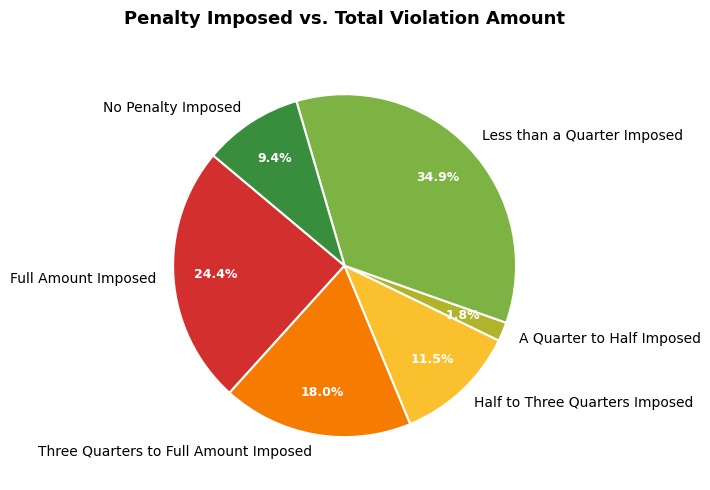

In [ ]:
# Overall proportions

violations_df_full['penalty_ratio_cat'] = violations_df_full.apply(classify_penalty_ratio, axis=1)
counts = violations_df_full['penalty_ratio_cat'].value_counts().reindex(PENALTY_CATEGORY_ORDER).dropna()

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    counts,
    labels=counts.index,
    autopct=lambda p: f'{p:.1f}%' if p > 1 else '',
    colors=PENALTY_CATEGORY_COLORS,
    startangle=140,
    pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)

for text in texts:
    text.set_fontsize(10)
for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax.set_title('Penalty Imposed vs. Total Violation Amount', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

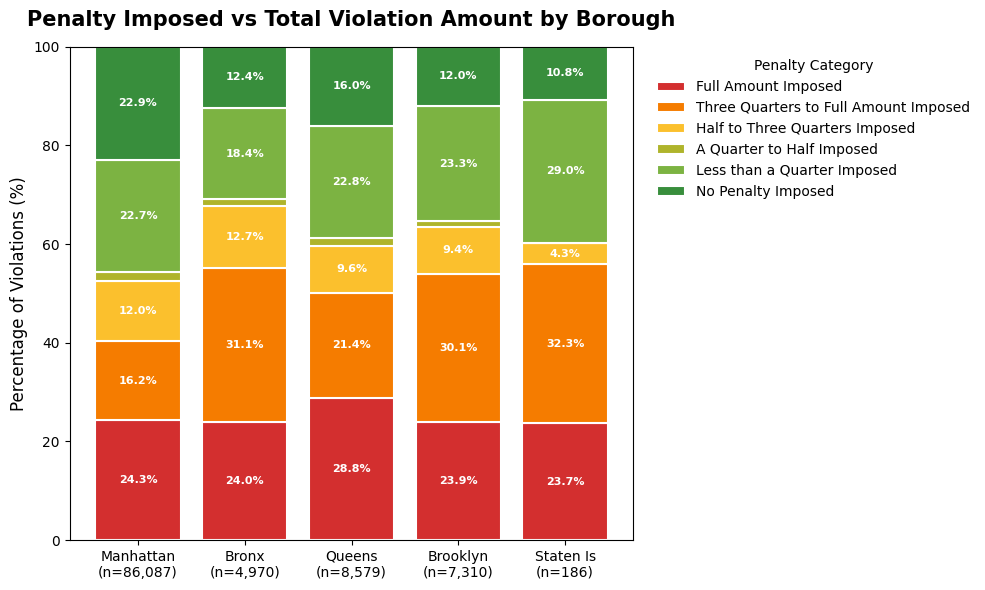

In [8]:
# Breakdown by Borough

prop_table, counts_n, boroughs = build_penalty_proportion_table(violations_df_full)

fig, ax = plt.subplots(figsize=(10, 6))

bottom = np.zeros(len(boroughs))
x_labels = [f'{b.title()}\n(n={counts_n[b]:,})' for b in boroughs]

for cat, color in zip(PENALTY_CATEGORY_ORDER, PENALTY_CATEGORY_COLORS):
    values = prop_table[cat].values
    ax.bar(x_labels, values, bottom=bottom, label=cat, color=color,
           edgecolor='white', linewidth=1.5)

    for i, v in enumerate(values):
        if v > 3:
            ax.text(i, bottom[i] + v / 2, f'{v:.1f}%',
                     ha='center', va='center', fontsize=8,
                     color='white', fontweight='bold')

    bottom += values

ax.set_ylabel('Percentage of Violations (%)', fontsize=12)
ax.set_ylim(0, 100)
ax.set_title('Penalty Imposed vs Total Violation Amount by Borough',
             fontsize=15, fontweight='bold', pad=15)
ax.legend(title='Penalty Category', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

plt.tight_layout()
plt.savefig(f"{DATA_DIR}/sanction_rate.png")
plt.show()

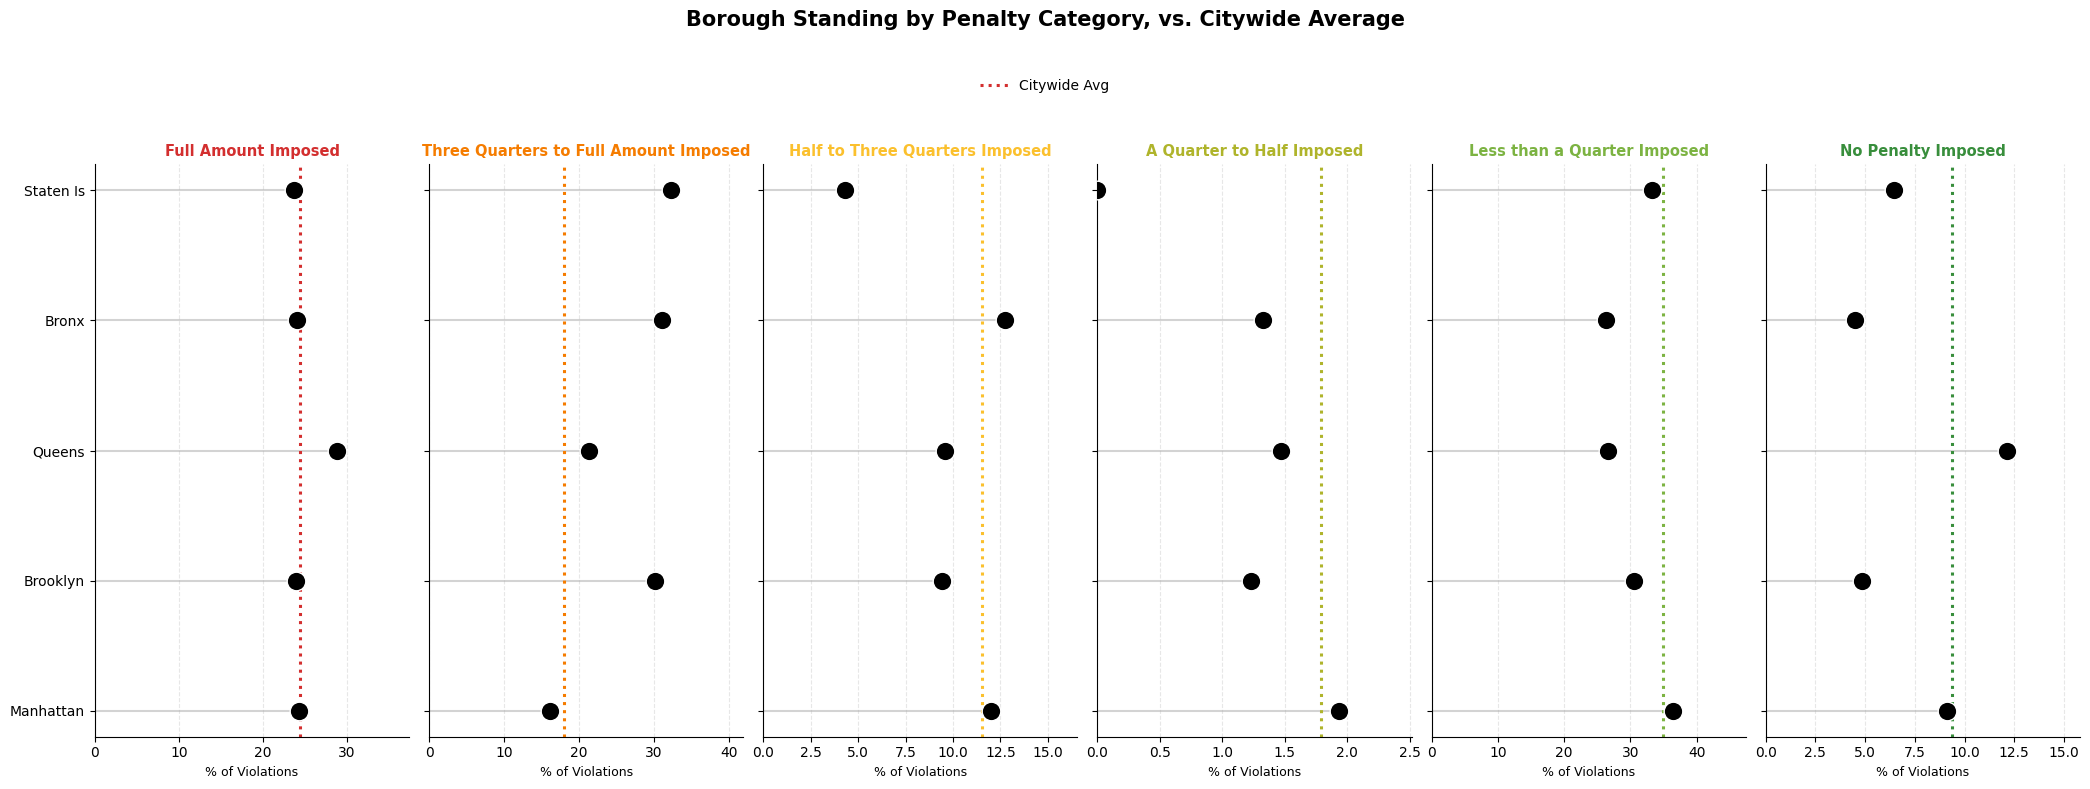

In [11]:
# Comparing to citywide averages

boroughs = ['MANHATTAN', 'BROOKLYN', 'QUEENS', 'BRONX', 'STATEN IS']
boroughs = [b for b in boroughs if b in violations_df_full['violation_location_borough'].unique()]

# Citywide percentages (across all boroughs combined)
citywide_counts = violations_df_full['penalty_ratio_cat'].value_counts().reindex(PENALTY_CATEGORY_ORDER).fillna(0)
citywide_pct = (citywide_counts / citywide_counts.sum() * 100).reindex(PENALTY_CATEGORY_ORDER)

# Per-borough percentages
borough_pct = {}
for b in boroughs:
    sub = violations_df_full[violations_df_full['violation_location_borough'] == b]
    counts = sub['penalty_ratio_cat'].value_counts().reindex(PENALTY_CATEGORY_ORDER).fillna(0)
    borough_pct[b] = (counts / counts.sum() * 100).reindex(PENALTY_CATEGORY_ORDER)

# Reshape into a category -> borough percentage lookup
cat_data = {cat: [borough_pct[b][cat] for b in boroughs] for cat in PENALTY_CATEGORY_ORDER}

n = len(PENALTY_CATEGORY_ORDER)
fig, axes = plt.subplots(1, n, figsize=(3.5 * n, 7), sharey=True)
if n == 1:
    axes = [axes]

y_pos = np.arange(len(boroughs))
borough_labels = [b.title() for b in boroughs]

for i, cat in enumerate(PENALTY_CATEGORY_ORDER):
    ax = axes[i]
    vals = cat_data[cat]
    avg = citywide_pct[cat]

    # Stem lines from 0 to each borough's dot
    ax.hlines(y_pos, 0, vals, color='lightgray', linewidth=1.5, zorder=1)

    # Black dots showing where each borough falls
    ax.scatter(vals, y_pos, s=180, color='black', edgecolor='white',
               linewidth=1, zorder=3)

    # Dotted vertical line for the citywide average of this category
    ax.axvline(x=avg, color=PENALTY_CATEGORY_COLORS[i], linestyle=':', linewidth=2.2, zorder=2,
               label='Citywide Avg' if i == 0 else None)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(borough_labels, fontsize=10)
    ax.set_title(cat, fontsize=10.5, fontweight='bold', color=PENALTY_CATEGORY_COLORS[i] if PENALTY_CATEGORY_COLORS[i] != '#BBDEFB' else '#1565C0')
    ax.set_xlabel('% of Violations', fontsize=9)
    ax.grid(axis='x', linestyle='--', alpha=0.3, zorder=0)
    ax.set_xlim(0, max(max(vals), avg) * 1.3)

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

# Shared legend for the dotted "citywide average" line
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.04),
           ncol=1, fontsize=10, frameon=False)

fig.suptitle('Borough Standing by Penalty Category, vs. Citywide Average', fontsize=15, fontweight='bold', y=1.12)
plt.tight_layout()
plt.show()

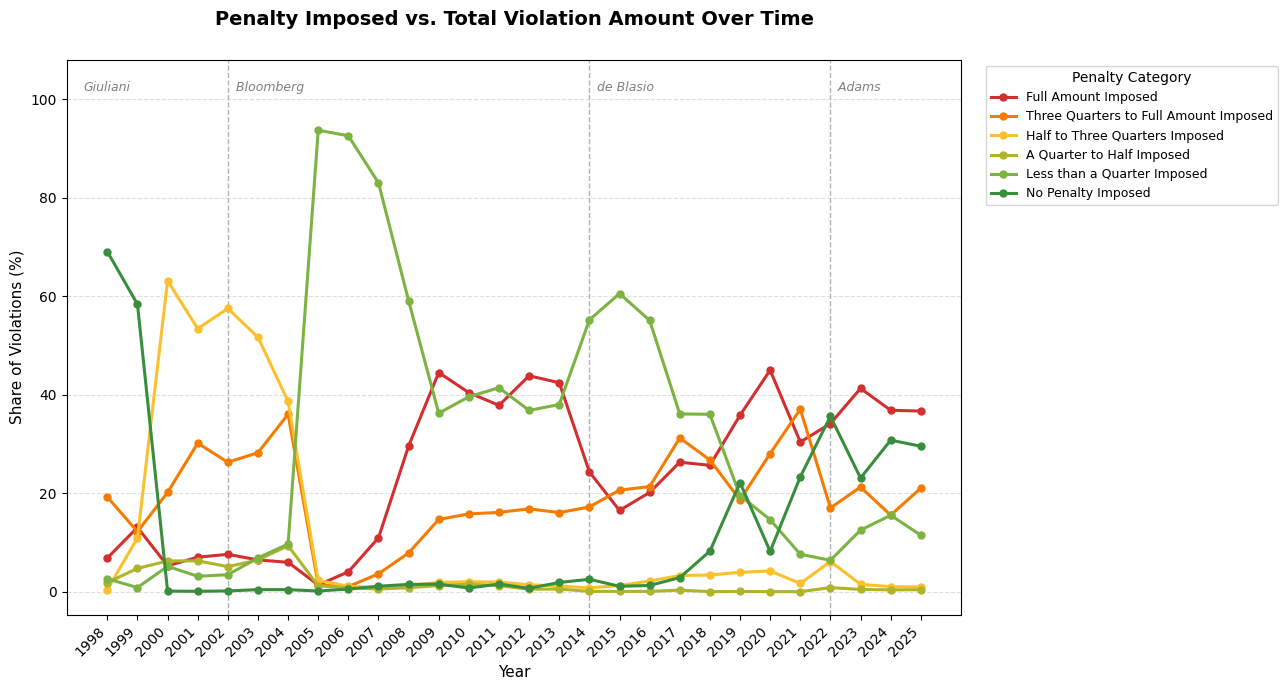

In [ ]:
# Visualizing shifts in sanction rate over time

order = ['Full Amount Imposed', 'Greater than Half Imposed', 'A Quarter to Half Imposed',
         'Less than Quarter Imposed', 'No Penalty Imposed']
colors = ['#2196F3', '#64B5F6', '#BBDEFB', '#90CAF9', '#B0BEC5']

grouped = (
    violations_df_full
    .groupby(['year', 'penalty_ratio_cat'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=PENALTY_CATEGORY_ORDER, fill_value=0)
    .sort_index()
)

# Convert to percentage of each year's total (set to False for raw counts instead)
use_percent = True
if use_percent:
    plot_data = grouped.div(grouped.sum(axis=1), axis=0) * 100
    ylabel = 'Share of Violations (%)'
else:
    plot_data = grouped
    ylabel = 'Number of Violations'

fig, ax = plt.subplots(figsize=(13, 7))

for cat, color in zip(PENALTY_CATEGORY_ORDER, PENALTY_CATEGORY_COLORS):
    if cat in plot_data.columns:
        ax.plot(
            plot_data.index,
            plot_data[cat],
            label=cat,
            color=color,
            marker='o',
            markersize=5,
            linewidth=2.2,
            zorder=3
        )

# Mayoral administration boundaries (term start years)
admin_boundaries = {
    2002: '  Bloomberg',
    2014: '  de Blasio',
    2022: '  Adams'
}

xmin, xmax = plot_data.index.min(), plot_data.index.max()
ymax = ax.get_ylim()[1] if not use_percent else 100

for year, name in admin_boundaries.items():
    if xmin <= year <= xmax:
        ax.axvline(x=year, color='gray', linestyle='--', linewidth=1, alpha=0.6, zorder=1)
        ax.text(
            year, ymax * 1.01, name,
            rotation=0, ha='left', va='bottom',
            fontsize=9, color='gray', style='italic'
        )

# Adding Giuliani administration
ax.text(1998, ymax * 1.01, "Giuliani",
            rotation=0, ha='center', va='bottom',
            fontsize=9, color='gray', style='italic')

ax.set_title('Penalty Imposed vs. Total Violation Amount Over Time', fontsize=14, fontweight='bold', pad=25)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel(ylabel, fontsize=11)
ax.legend(title='Penalty Category', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_xticks(plot_data.index)
ax.set_ylim(top=ymax * 1.08)  # headroom for admin labels
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Dismissed charges

In [5]:
dismissed_df = (violations_df_full[violations_df_full['hearing_result'].str.upper().str.startswith("DISMISSED", na=False)])

print("Number of charges that were dismissed:", len(dismissed_df))
print("\nPercentage of charges that were dismissed:", round(len(dismissed_df) / len(violations_df_full) * 100, 3), "%")

Number of charges that were dismissed: 23731

Percentage of charges that were dismissed: 21.659 %


<Axes: title={'center': 'Breakdown of Dismissed Charges by Enforcement Agency'}>

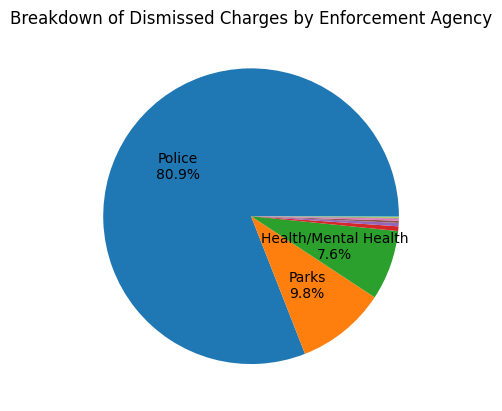

In [7]:
# Breakdown by enforcement agency

agency_grouped = dismissed_df.groupby("agency_normalized").size().sort_values(ascending=False)

total = agency_grouped.sum()
top3 = agency_grouped.index[:3].tolist()

def label_top3(pct):
    count = round(pct / 100 * total)
    match = agency_grouped[abs(agency_grouped - count) <= 1]
    if not match.empty and match.index[0] in top3:
        name = match.index[0]
        return f"{name}\n{pct:.1f}%"
    return ""

agency_grouped.plot(kind="pie", labels=[""] * len(agency_grouped),
                    autopct=label_top3, ylabel="", title = "Breakdown of Dismissed Charges by Enforcement Agency")

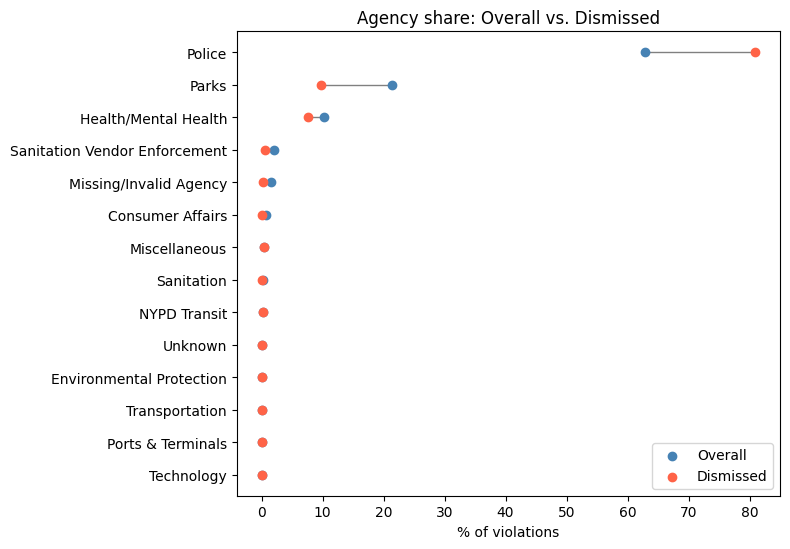

In [9]:
#  Build the comparison table
overall_pct = violations_df_full['agency_normalized'].value_counts(normalize=True) * 100
dismissed_pct = dismissed_df['agency_normalized'].value_counts(normalize=True) * 100

compare_df = pd.DataFrame({
    'Overall': overall_pct,
    'Dismissed': dismissed_pct
}).fillna(0)

# sort by overall share so the dot plot reads high-to-low
compare_df = compare_df.sort_values('Overall', ascending=True)

# Cleveland Dot plot
fig, ax = plt.subplots(figsize=(8, len(compare_df) * 0.4))

for i, (agency, row) in enumerate(compare_df.iterrows()):
    ax.plot([row["Overall"], row["Dismissed"]], [i, i], color="gray", lw=1)
    ax.scatter(row["Overall"], i, color="steelblue", zorder=3, label="Overall" if i == 0 else "")
    ax.scatter(row["Dismissed"], i, color="tomato", zorder=3, label="Dismissed" if i == 0 else "")

ax.set_yticks(range(len(compare_df)))
ax.set_yticklabels(compare_df.index)
ax.set_xlabel("% of violations")
ax.set_title("Agency share: Overall vs. Dismissed")
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Saving Dataframes**

In [15]:
cc_analysis.to_file(f"{PRO_DATA_DIR}/cc_analysis.geojson", driver = 'GeoJSON', index = False)